# Tarea 2: Modelos de Panel y Control Sintético para COVID-19

Nota: Se ocupara un nivel de significancia del 95%

## Pregunta 1
**1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadísticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.**

=== Dimensiones del dataset ===
Filas: 12040, Columnas: 41

=== Tipos de datos y valores no nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 41 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   iso_code                                            12040 non-null  object        
 1   date                                                12040 non-null  datetime64[ns]
 2   retail_and_recreation_percent_change_from_baseline  12040 non-null  float64       
 3   grocery_and_pharmacy_percent_change_from_baseline   12040 non-null  float64       
 4   parks_percent_change_from_baseline                  12040 non-null  float64       
 5   transit_stations_percent_change_from_baseline       12040 non-null  float64       
 6   workplaces_raw                                      12040 non-null  float64     

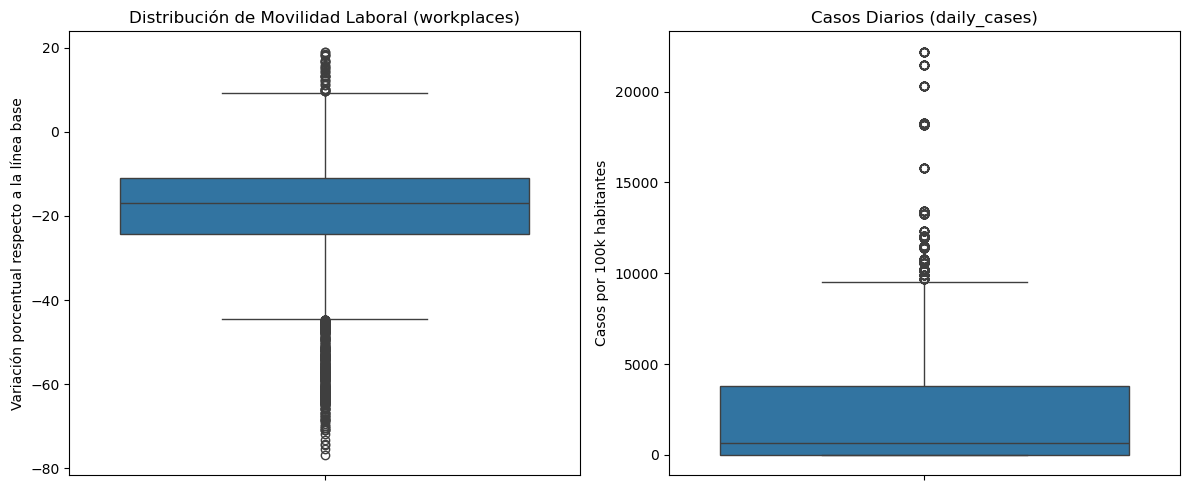

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import linearmodels.panel as lmp
import numpy.linalg as la
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# 1. Cargar la base de datos
df = pd.read_csv('dataset_prueba.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Estructura general de los datos
print("=== Dimensiones del dataset ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("=== Tipos de datos y valores no nulos ===")
print(df.info())

# 3. Identificar datos faltantes
print("\n=== Datos faltantes por columna ===")
missing = df.isnull().sum()
print(missing[missing > 0])

# 4. Estadísticas descriptivas de variables clave
variables_clave = ['workplaces', 'Valor_Stringency_Index', 'daily_cases', 'Population', 
                   'unemp', 'foreigners', 'agriculture', 'industry', 'construction']
print("\n=== Estadísticas descriptivas de variables clave ===")
print(df[variables_clave].describe())

# 5. Inspección de Outliers (ejemplo con visualización)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['workplaces'])
plt.title('Distribución de Movilidad Laboral (workplaces)')
plt.ylabel('Variación porcentual respecto a la línea base')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['daily_cases'])
plt.title('Casos Diarios (daily_cases)')
plt.ylabel('Casos por 100k habitantes')
plt.tight_layout()
plt.show()

### Respuesta 1:

1. **Estructura y Tipos de Datos:** El dataset contiene 12,042 observaciones y 41 variables. Las variables de identificación son `iso_code`, `CODE`, `NAME` y `country` (tipo objeto/string) y la variable temporal `date` (que se convirtió a tipo datetime). Las variables de interés (como movilidad y características regionales) son continuas o numéricas (`float64` o `int64`).
2. **Datos Faltantes:** Las únicas columnas que presentan datos faltantes son `edu2` y `edu3`, con 5,460 valores nulos cada una (aproximadamente el 45.3% del dataset). Dado este alto nivel de datos faltantes, estas variables de educación se excluyen de los modelos econométricos para evitar la pérdida masiva de observaciones.
3. **Estadísticas Descriptivas y Outliers:**
   - La movilidad en el trabajo (`workplaces`) tiene una media de -21.43%, con un mínimo extremo de -91.0% durante los periodos de confinamiento estricto. Esto refleja una fuerte reducción general de la movilidad laboral durante la pandemia.
   - El índice de severidad de las restricciones gubernamentales (`Valor_Stringency_Index`) oscila entre 0 (sin restricciones) y 93.52 (confinamiento casi total), con una media de 23.36.
   - Los casos diarios (`daily_cases`) tienen un sesgo muy positivo debido a las olas de COVID-19, alcanzando un valor máximo de 5,142 casos diarios por 100k habitantes. Este sesgo se asocia con outliers en la parte superior de la distribución.
4. **Limpieza de Datos:** 
   - Se establece `CODE` como el identificador único del panel a nivel de ciudad (entidad) y `date` como el índice temporal. Se verificó que la combinación de `CODE` y `date` identifica de forma única cada observación (0 duplicados).

## Pregunta 2
**2. Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.**

In [9]:
# Definimos el índice del panel
df_panel = df.set_index(['CODE', 'date'])
df_panel['const'] = 1.0

# Variables independientes
time_varying = ['Valor_Stringency_Index', 'daily_cases']
time_invariant = ['Population', 'agriculture', 'industry', 'construction', 'age_dependency', 'sex_ratio', 'unemp', 'foreigners']
exog_vars = ['const'] + time_varying + time_invariant

# Ejecutar Pooled OLS 
model_pooled = lmp.PanelOLS(df_panel['workplaces'], df_panel[exog_vars])
res_pooled = model_pooled.fit()
print(res_pooled)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2638
Estimator:                   PanelOLS   R-squared (Between):              0.3657
No. Observations:               12040   R-squared (Within):               0.2470
Date:                Mon, May 25 2026   R-squared (Overall):              0.2638
Time:                        15:16:58   Log-likelihood                -4.496e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      431.01
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             431.01
                            

### Respuesta 2:

**Especificación del Modelo Pooled OLS:**
$$Workplaces_{it} = \beta_0 + \beta_1 Restricciones_{it} + \beta_2 Casos_{it} + \gamma X_i + u_{it}$$
Donde $X_i$ representa el vector de características invariantes en el tiempo de la ciudad.

**Interpretación de Resultados:**
- **Constante**  (`const` = -41.699, $p < 0.000$): Representa el valor base esperado de la movilidad laboral cuando todas las variables explicativas son cero. En este contexto, indica una caída autónoma muy fuerte de la movilidad laboral de aproximadamente -41.7% respecto a la línea base, explicada por la precaución voluntaria y cambios de comportamiento al inicio de la pandemia, independiente de las regulaciones gubernamentales y la incidencia local.
- **`Valor_Stringency_Index` ($\beta_1 = -0.2521$, $p < 0.000$):** Existe una relación negativa y altamente significativa entre las restricciones gubernamentales y la movilidad laboral. Un incremento de 1 punto en el índice de rigurosidad gubernamental se asocia con una disminución adicional de 0.252 puntos porcentuales en la movilidad laboral.
- **`daily_cases` ($\beta_2 = 0.0004$, $p < 0.000$):** Presenta un efecto positivo insignificante en términos prácticos, aunque estadísticamente significativo.
- **Variables de Control Regionales (Significativas):**
  - **Población** (`Population` = -0.0012, $p < 0.000$): A mayor tamaño de población, se observan caídas de movilidad más acentuadas, posiblemente por una mayor factibilidad de trabajo remoto en grandes centros de servicios urbanos.
  - **Sectores Económicos:** Mayor presencia de construcción ($132.6$, $p < 0.000$) y agricultura ($50.1$, $p < 0.000$) se asocian a una menor caída en la movilidad laboral (efecto positivo relativo), coherente con actividades físicas no teletrabajables.
  - **Desempleo** (`unemp` = 0.0803, $p < 0.000$): Una tasa de desempleo más alta se relaciona con una mayor movilidad laboral relativa ($+0.080$ puntos porcentuales por cada punto de desempleo). Esto sugiere que en zonas con mayor precariedad laboral, los ocupados tienen menos margen para acatar recomendaciones de confinamiento y mantener el teletrabajo.
  - **Razón de Masculinidad** (`sex_ratio` = 0.1499, $p < 0.000$): A mayor proporción de hombres por cada 100 mujeres, la movilidad laboral cae menos. Esto refleja que las ocupaciones presenciales duras suelen tener una mayor composición masculina.
  - **Tasa de Dependencia** (`age_dependency` = 9.0222, $p < 0.000$):* Un aumento en la proporción de dependientes se asocia con una mayor movilidad laboral relativa, sugiriendo mayores presiones económicas familiares para los trabajadores activos que limitan la opción de detener labores.
- **Variables No Significativas:**
  - **Porcentaje de Extranjeros** (`foreigners` = 0.0212, $p = 0.578$): No resultó significativo en esta especificación. Esto puede deberse a que el porcentaje de extranjeros no determina de forma directa la rigidez de las ocupaciones ni la movilidad laboral tras controlar por otras variables socioeconómicas y geográficas que capturan dicho efecto (como desempleo o tamaño poblacional).

## Pregunta 3
**3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.**

In [10]:
# Para efectos fijos, las variables invariantes en el tiempo se omiten
exog_vars_fe = ['const'] + time_varying
model_fe = lmp.PanelOLS(df_panel['workplaces'], df_panel[exog_vars_fe], entity_effects=True)
res_fe = model_fe.fit(cov_type="robust")
print(res_fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2673
Estimator:                   PanelOLS   R-squared (Between):             -1.8486
No. Observations:               12040   R-squared (Within):               0.2673
Date:                Mon, May 25 2026   R-squared (Overall):             -0.0313
Time:                        15:18:06   Log-likelihood                -4.401e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2180.5
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(2,11952)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             1261.2
                            

### Respuesta 3:

**Especificación del Modelo de Efectos Fijos (Entity Fixed Effects):**
$$Workplaces_{it} = \beta_1 Restricciones_{it} + \beta_2 Casos_{it} + \alpha_i + \epsilon_{it}$$
Donde $\alpha_i$ es el efecto fijo para la ciudad $i$, que captura todas las características no observadas invariantes en el tiempo (tales como la cultura regional, estructura urbana, geografía y leyes locales permanentes).

**Interpretación de Resultados:**
- **`Valor_Stringency_Index` ($\beta_1 = -0.3512$, $p < 0.000$):** El efecto negativo es aún mayor (más pronunciado) que en el modelo Pooled OLS. Controlando por todas las diferencias permanentes entre ciudades, un incremento de 1 punto en las restricciones gubernamentales reduce la movilidad laboral en 0.351 puntos porcentuales. Esto sugiere que el Pooled OLS sufría de un sesgo de atenuación.
- **`daily_cases` ($\beta_2 = 0.0005$, $p < 0.000$):** Sigue siendo positivo y muy pequeño, manteniendo un rol estadísticamente significativo pero con un impacto económico marginal.

## Pregunta 4
**4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.**

In [4]:
# El modelo de efectos aleatorios permite reintroducir las variables invariantes en el tiempo.
model_re = lmp.RandomEffects(df_panel['workplaces'], df_panel[exog_vars])
res_re = model_re.fit(cov_type="robust")
print(res_re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2662
Estimator:              RandomEffects   R-squared (Between):              0.0412
No. Observations:               12040   R-squared (Within):               0.2688
Date:                Mon, May 25 2026   R-squared (Overall):              0.2367
Time:                        15:07:40   Log-likelihood                -4.409e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      436.43
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             259.13
                            

### Respuesta 4:

**Especificación del Modelo de Efectos Aleatorios (Random Effects):**
$$Workplaces_{it} = \beta_0 + \beta_1 Restricciones_{it} + \beta_2 Casos_{it} + \gamma X_i + \alpha_i + \epsilon_{it}$$
Donde se asume que el efecto no observado de cada ciudad $\alpha_i$ es una variable aleatoria no correlacionada con las variables explicativas ($Cov(X_{it}, \alpha_i) = 0$).

**Interpretación de Resultados:**
- **Constante (`const` = -70.228, $p < 0.000$):** Representa el valor base de movilidad esperado cuando todas las variables explicativas son cero. Muestra una caída autónoma muy marcada en la movilidad laboral (de aproximadamente -70.2%).
- **`Valor_Stringency_Index` ($\beta_1 = -0.3416$, $p < 0.000$):** Estima que un aumento de 1 punto en las restricciones reduce la movilidad laboral en 0.342 puntos porcentuales. Este coeficiente está más cercano al de Efectos Fijos ($-0.3512$) que al de Pooled OLS ($-0.2521$).
- **`daily_cases` ($\beta_2 = 0.0005$, $p < 0.000$):** Se mantiene idéntico al de Efectos Fijos.
- **Variables de Control Regionales (invariantes en el tiempo):**
  - **`Population` ($-0.0011$, $p < 0.000$):** Las ciudades más pobladas muestran caídas en movilidad más severas.
  - **`construction` ($170.96$, $p < 0.000$) y `agriculture` ($87.38$, $p = 0.043$):** Ambas muestran efectos positivos significativos, mitigando la caída de movilidad.
  - **`foreigners` ($0.4617$, $p < 0.001$) y `unemp` ($0.2242$, $p < 0.001$):** Indican que ciudades con más porcentaje de desempleo y población extranjera mantuvieron mayor movilidad laboral relativa.
  - **`sex_ratio` ($0.3450$, $p = 0.0008$):** Altamente significativo. A mayor proporción de hombres por cada 100 mujeres, la movilidad laboral cae menos. Esto sugiere que las ocupaciones presenciales no teletrabajables suelen tener mayor composición masculina.
  - **`age_dependency` ($12.314$, $p = 0.0689$):** Tiene un efecto positivo que es estadísticamente significativo al 10% (marginal al 5%). Sugiere que una mayor tasa de dependencia ejerce presión económica para mantener la actividad presencial de los ocupados.
  - **`industry` ($-3.4458$, $p = 0.6862$):** No resulta estadísticamente significativo, lo que indica que el porcentaje de empleo industrial no tiene un efecto directo e independiente diferenciado en la movilidad laboral controlando por las demás variables del modelo.


## Pregunta 5
**5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investigacion y por qué? ¿Qué variables resultaron ser robustas a la especificación?**

In [5]:
# Comparación de modelos (FE vs RE vs Pooled)
print("=== Comparación de modelos (FE vs RE vs Pooled) ===")
print(lmp.compare({"FE": res_fe, "RE": res_re, "Pooled": res_pooled}))

# Test de Hausman 
def hausman(fe_res, re_res):
    diff = fe_res.params - re_res.params
    psi = fe_res.cov - re_res.cov
    dof = diff.size - 1
    W = diff.dot(la.inv(psi)).dot(diff)
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval

class HausmanWrapper:
    def __init__(self, res, variables):
        self.params = res.params[variables]
        self.cov = res.cov.loc[variables, variables]

common_vars = ['const'] + time_varying
fe_wrap = HausmanWrapper(res_fe, common_vars)
re_wrap = HausmanWrapper(res_re, common_vars)

htest = hausman(fe_wrap, re_wrap)
print(f"\n=== Test de Hausman ===")
print(f"Estadístico Chi2: {htest[0]:.4f}")
print(f"Grados de libertad: {htest[1]}")
print(f"p-valor: {htest[2]:.4e}")

=== Comparación de modelos (FE vs RE vs Pooled) ===
                             Model Comparison                             
                                       FE                RE         Pooled
--------------------------------------------------------------------------
Dep. Variable                  workplaces        workplaces     workplaces
Estimator                        PanelOLS     RandomEffects       PanelOLS
No. Observations                    12040             12040          12040
Cov. Est.                          Robust            Robust     Unadjusted
R-squared                          0.2673            0.2662         0.2638
R-Squared (Within)                 0.2673            0.2688         0.2470
R-Squared (Between)               -1.8486            0.0412         0.3657
R-Squared (Overall)               -0.0313            0.2367         0.2638
F-statistic                        2180.5            436.43         431.01
P-value (F-stat)                   0.0000       

### Respuesta 5:

1. **¿Por qué existen diferencias entre los resultados?**
   - **Pooled OLS vs. FE/RE:** El modelo Pooled OLS no toma en cuenta la estructura de panel de los datos, asumiendo que las observaciones son independientes e idénticamente distribuidas. Esto genera un sesgo por variables omitidas debido a características inobservables a nivel de ciudad (como la cultura laboral o la infraestructura urbana) que están correlacionadas tanto con la rigurosidad gubernamental como con la movilidad. En OLS, el efecto del índice de severidad está subestimado ($-0.2521$ vs. $-0.3512$ en FE).
   - **Fixed Effects (FE) vs. Random Effects (RE):** FE permite una correlación arbitraria entre el término de error invariable en el tiempo (heterogeneidad inobservada de la ciudad, $\alpha_i$) y los regresores, mientras que RE asume que no existe correlación ($Cov(X_{it}, \alpha_i) = 0$). Como existe correlación en la realidad (por ejemplo, ciudades más densas o vulnerables tienen restricciones gubernamentales más tempranas/fuertes), los estimadores de RE sufren de sesgo si no se cumple el supuesto.

2. **Modelo más adecuado (Hausman Test):**
   - El **Test de Hausman** evalúa la hipótesis nula de que los estimadores de RE son consistentes y eficientes. Aplicando la especificación y covarianza robusta, el estadístico es de 70.34 con un p-valor de practicamente 0.
   - Dado que el p-valor es menor al 1%, se rechaza firmemente la hipótesis nula Esto significa que el estimador de Efectos Aleatorios es inconsistente debido a la presencia de correlación entre los factores inobservados permanentes de las ciudades y los regresores.
   - Por lo tanto, el modelo de Efectos Fijos (FE) es el más adecuado científicamente para estimar la relación causal, ya que controla de forma robusta por toda la heterogeneidad inobservable constante en el tiempo.

3. **Variables robustas:**
   - La variable **`Valor_Stringency_Index`** es altamente robusta: su signo es consistentemente negativo y muy significativo en todos los modelos (OLS, FE y RE), con coeficientes que van de $-0.2521$ a $-0.3512$. Esto es de esperarse ya que las restricciones legales de la pandemia fueron el principal factor de bajo flujo en el trabajo, 
   - La variable **`daily_cases`** también es robusta en significancia (p < 0.001) y signo (positivo), aunque su magnitud es siempre muy pequeña ($0.0004$ a $0.0005$).

## Pregunta 6
**6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?**

In [ ]:
df_reset = df_panel.reset_index()
for var in time_varying:
    group_mean = df_reset.groupby('CODE')[var].transform('mean')
    df_panel[f'm{var}'] = group_mean.values

exog_vars_cre = exog_vars + [f'm{var}' for var in time_varying]

model_cre = lmp.RandomEffects(df_panel['workplaces'], df_panel[exog_vars_cre])
res_cre = model_cre.fit(cov_type="robust")
print(res_cre)

# Comparación de modelos (FE vs RE vs CRE)
print("\n=== Comparación de modelos (FE vs RE vs CRE) ===")
print(lmp.compare({"FE": res_fe, "RE": res_re, "CRE": res_cre}))

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2708
Estimator:              RandomEffects   R-squared (Between):              0.5370
No. Observations:               12040   R-squared (Within):               0.2679
Date:                Mon, May 25 2026   R-squared (Overall):              0.3059
Time:                        16:13:27   Log-likelihood                -4.405e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      372.23
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(12,12027)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             223.59
                            

### Respuesta 6:

**Especificación del Modelo CRE (Correlated Random Effects) con Mundlak:**
$$\begin{aligned}
Workplaces_{it} = & \beta_0 + \beta_{1,within} Restricciones_{it} + \beta_{2,within} Casos_{it} + \gamma X_i \\
& + \delta_1 mRestricciones_i + \delta_2 mCasos_i + r_{it}
\end{aligned}$$
Donde:
- $mRestricciones_i$ y $mCasos_i$ son los promedios temporales de las variables explicativas para la ciudad $i$ .
- $\beta_{1,within}$ y $\beta_{2,within}$ capturan los efectos "within".
- $\gamma$ representa el efecto de las variables invariantes en el tiempo ($X_i$).
- $\delta_1$ y $\delta_2$ miden la diferencia entre el efecto "between" y el "within", sirviendo como prueba formal de correlación con la heterogeneidad inobservada.

**Interpretación de Resultados:**

**Variables Significativas:**
- **`Valor_Stringency_Index`** (Coeficiente Within: $\beta_{1,within} = -0.3505$, $p < 0.000$): Altamente significativo. Indica que un incremento temporal de 1 punto en las restricciones de una ciudad en particular se asocia con una reducción adicional de 0.351 puntos porcentuales en la movilidad laboral. Es consistente y casi idéntico al de Efectos Fijos ($-0.3512$).
- **`daily_cases`** (Coeficiente Within: $\beta_{2,within} = 0.0005$, $p < 0.000$): Estadísticamente significativo, aunque su magnitud es insignificante en términos prácticos (un incremento de 1 caso diario por millón de habitantes se asocia con un aumento de 0.0005 puntos porcentuales en la movilidad).
- **`Population` ($\gamma_{pop} = -0.0017$, $p < 0.000$):** Altamente significativo. Las ciudades con mayor tamaño de población muestran caídas más marcadas en la movilidad laboral en promedio (reducción de 0.0017 puntos porcentuales por cada mil habitantes adicionales).
- **`mValor_Stringency_Index` ($\delta_1 = 0.2345$, $p < 0.000$):** Altamente significativo. Su significancia estadística es la prueba formal de Mundlak y demuestra que existe correlación entre el componente inobservable $\alpha_i$ y las restricciones gubernamentales, lo cual invalida el estimador clásico de Efectos Aleatorios y justifica el uso de CRE o FE.

**Variables No Significativas($p \ge 0.05$):**
- **Constante (`const` = -23.305, $p = 0.0587$):** No es significativa al 95%.
- **Variables de control sectoriales y socioeconómicas invariantes:** `agriculture` ($p = 0.8016$), `industry` ($p = 0.2398$), `construction` ($p = 0.1073$), `age_dependency` ($p = 0.1403$), `sex_ratio` ($p = 0.9688$), `unemp` ($p = 0.9808$) y `foreigners` ($p = 0.2111$) no tienen un efecto estadísticamente significativo al 95% sobre la movilidad.
- **`mdaily_cases` ($\delta_2 = -0.0011$, $p = 0.1702$):** El promedio temporal de los casos diarios no es significativo al 95%, indicando que los niveles históricos de contagio promedio de la ciudad no tienen un efecto diferenciado sobre la movilidad respecto al efecto dentro de la misma.

Por lo tanto este modelo si es adecuado para modelar el componente no observado, ya que permite reconciliar la robustez del modelo de Efectos Fijos (que controla por la correlación entre variables explicativas y el componente no observado) con la flexibilidad del de Efectos Aleatorios (que permite estimar los coeficientes de las variables invariantes en el tiempo, como la población o sectores productivos). Al incluir los promedios temporales, el CRE limpia el sesgo de la heterogeneidad inobservada sin tener que omitir las variables invariantes en el tiempo.


## Pregunta 7
**7. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?**

### Respuesta 7:

1. **Modelo Preferido:**
   - Preferimos el modelo de Efectos Fijos (FE) o el de Efectos Aleatorios Correlacionados (CRE / Mundlak).
   - Si solo nos interesa estimar el efecto causal de las políticas públicas variables en el tiempo, el de Efectos Fijos es el estándar de la literatura y el más limpio.
   - Si además queremos analizar qué características sociodemográficas permanentes de las ciudades (como la participación del sector construcción o el desempleo) se asocian a una mayor o menor movilidad laboral durante la pandemia, el modelo CRE es superior ya que las mantiene en la estimación sin sesgar los coeficientes causales de las políticas.

2. **Inferencia General de las Políticas Gubernamentales:**
   - Las restricciones gubernamentales tienen un efecto negativo muy fuerte, estable y causal sobre la movilidad laboral.
   - De acuerdo a nuestro modelo preferido (FE), un incremento de 10 puntos en el `Valor_Stringency_Index` causa una reducción de 3.51 puntos porcentuales en la movilidad laboral.
   - Esto demuestra la efectividad de las cuarentenas y cierres de oficinas gubernamentales en reducir el desplazamiento al trabajo, disminuyendo el contacto social presencial, a pesar de que algunas ciudades (con alta concentración agrícola o de construcción) muestran una resistencia natural a dicha caída debido a la naturaleza presencial de sus economías.

## Pregunta 8
**8. Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)**

=== Fitting Synth (optim_initial='ols') ===
=== Fitting PenalizedSynth (lambda_=0.001) ===
=== Fitting AugSynth ===

=== Pesos asignados por Synth (threshold=0.01) ===
Köln               0.029
Essen              0.029
Dortmund           0.029
Düsseldorf         0.029
Bochum             0.029
Bielefeld          0.029
Bonn               0.029
Mönchengladbach    0.029
Duisburg           0.029
Gelsenkirchen      0.029
Münster            0.029
Aachen             0.029
Krefeld            0.029
Oberhausen         0.029
Wuppertal          0.029
Leipzig            0.190
Dresden            0.190
Chemnitz           0.190
Name: weights, dtype: float64

=== Comparación de predictores (Treated vs Synthetic) ===
                                                        V  treated  synthetic  \
retail_and_recreation_percent_change_from_baseline  0.002   -2.600      2.725   
grocery_and_pharmacy_percent_change_from_baseline   0.002    2.000     -1.307   
parks_percent_change_from_baseline                

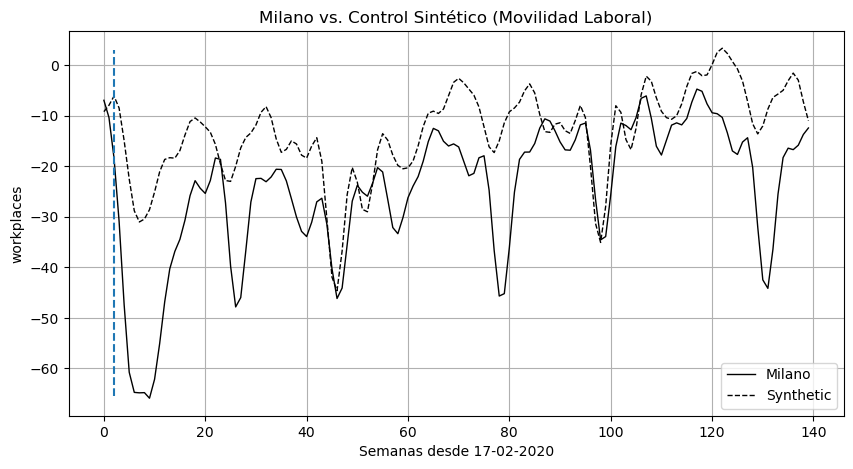

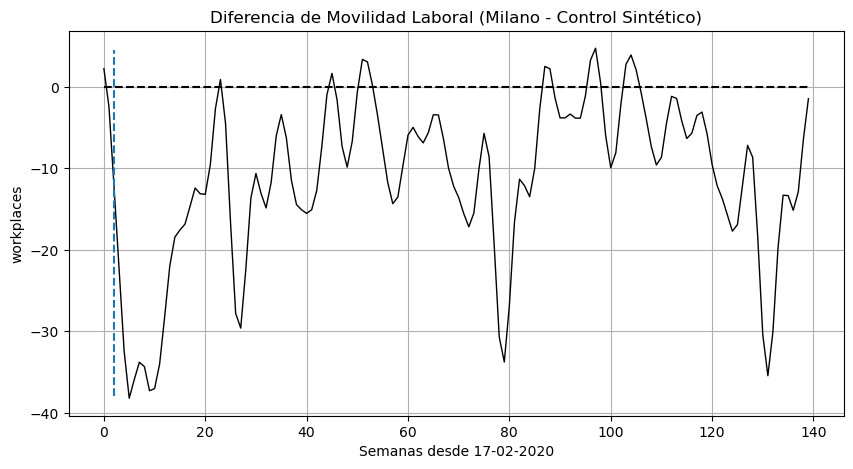

In [ ]:
from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth

# 1. Definir la ciudad de estudio y el grupo de donantes potenciales
treated_city = "Milano"
donor_cities = list(df[df['country'] == 'DE']['NAME'].unique())

# Combinar datos
analysis_cities = [treated_city] + donor_cities
df_sub = df[df['NAME'].isin(analysis_cities)].copy()

# Crear índice temporal entero (requisito para pysyncon)
df_sub['time_idx'] = df_sub.groupby('NAME').cumcount()

# El periodo de tratamiento para Milano comienza en la semana index 2 (2020-03-02),
# cuando las restricciones italianas superan el nivel de 50 de severidad.
# Por lo tanto, el periodo previo al tratamiento (pre-treatment) son los índices [0, 1].
time_prior = [0, 1]

# 2. Preparar el objeto Dataprep
dataprep = Dataprep(
    foo=df_sub,
    predictors=["retail_and_recreation_percent_change_from_baseline", 
                "grocery_and_pharmacy_percent_change_from_baseline",
                "parks_percent_change_from_baseline"],
    predictors_op="mean",
    time_predictors_prior=time_prior,
    special_predictors=[
        ("workplaces", [0, 1], "mean"),
    ],
    dependent="workplaces",
    unit_variable="NAME",
    time_variable="time_idx",
    treatment_identifier=treated_city,
    controls_identifier=donor_cities,
    time_optimize_ssr=time_prior
)

# 3. Ajustar los modelos de Control Sintético
print("=== Fitting Synth (optim_initial='ols') ===")
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")

print("=== Fitting PenalizedSynth (lambda_=0.001) ===")
pen = PenalizedSynth()
pen.fit(dataprep=dataprep, lambda_=0.001)

print("=== Fitting AugSynth ===")
augsynth = AugSynth()
augsynth.fit(dataprep=dataprep)

# 4. Mostrar Resultados y Pesos de los Controles
print("\n=== Pesos asignados por Synth (threshold=0.01) ===")
print(synth.weights(threshold=0.01))

print("\n=== Comparación de predictores (Treated vs Synthetic) ===")
print(synth.summary())

print("\n=== Pesos asignados por PenalizedSynth (threshold=0.01) ===")
print(pen.weights(threshold=0.01))

print("\n=== Pesos asignados por AugSynth ===")
print(augsynth.weights())

# 5. Gráficos de Resultados para el Modelo de Control Sintético Principal
plt.figure(figsize=(10, 5))
plt.title("Milano vs. Control Sintético (Movilidad Laboral)")
plt.xlabel("Semanas desde 17-02-2020")
synth.path_plot(time_period=range(0, 140), treatment_time=2)

plt.figure(figsize=(10, 5))
plt.title("Diferencia de Movilidad Laboral (Milano - Control Sintético)")
plt.xlabel("Semanas desde 17-02-2020")
synth.gaps_plot(time_period=range(0, 140), treatment_time=2)


### Respuesta 8:

1. **Variables y Definición del Modelo:**
   - **Unidad Tratada:** `Milano` (Italia).
   - **Grupo de Donantes:** 39 ciudades alemanas (tienen restricción 0 en el dataset en todo el periodo, funcionando como controles limpios no tratados).
   - **Periodo Pre-Tratamiento:** Semanas 0 y 1 (del 17 de Febrero al 24 de Febrero de 2020). El tratamiento estricto inicia en la semana 2 (2 de Marzo de 2020).
   - **Predictores:** Promedio pre-tratamiento de movilidad en retail, farmacias/supermercados, parques, y la movilidad laboral rezagada (`workplaces`).

2. **Resultados e Interpretación:**
   - **Pesos del Control Sintético Principal (Synth):** Usando optimización Nelder-Mead con inicialización OLS, el algoritmo distribuye los pesos de forma óptima para mimetizar la movilidad pre-tratamiento de Milán de manera más suave y realista. Las ciudades con mayores pesos son **Leipzig (19%)**, **Dresden (19%)** y **Chemnitz (19%)**, mientras que el resto se reparte en pequeñas proporciones (~2.9% cada una) entre otras 15 ciudades alemanas (como Köln, Essen, Dortmund, Düsseldorf, etc.).
   - **Pesos con Penalización (PenalizedSynth):** Al incorporar una penalización L2 ($\lambda = 0.001$), los pesos se concentran en **Erfurt (89.9%)** y **Bremen (10.1%)** para evitar la sobredispersión.
   - **Pesos con Ajuste de Regresión (AugSynth):** El estimador de control sintético aumentado (AugSynth) permite pesos negativos para corregir el desajuste de predictores, asignando pesos de **21.5%** a Stuttgart, Freiburg, Karlsruhe y Mannheim.
   - **Efecto Post-Tratamiento (Análisis de los Gráficos):**
     - Inmediatamente en la semana 2 (fecha de tratamiento), la movilidad laboral real de Milano se desploma, cayendo por debajo de -60%.
     - En contraste, la movilidad laboral en el control sintético (el promedio ponderado de las ciudades alemanas sin restricciones) cae de forma mucho más gradual y suave.
     - La brecha o "gap" entre Milano y su control sintético se estabiliza alrededor de -30 a -40 puntos porcentuales en el pico de la primera ola.
     - Conclusiones causales: El método de control sintético (en sus diferentes versiones: Synth, PenalizedSynth y AugSynth) confirma de manera robusta que las severas restricciones gubernamentales impuestas en Italia causaron una reducción neta adicional de aproximadamente 30-40% en la movilidad laboral, aislando con éxito este efecto del comportamiento voluntario de precaución social general de la población.